##✅ TASK 4: Sentiment Analysis
Goal: Classify text as Positive, Negative, or Neutral using NLP.
We'll analyze Amazon product reviews.

##Step 1 — Install & Import

In [1]:
!pip install vaderSentiment textblob wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import re
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.6 MB/s eta 0:00:00
✅ Libraries ready!


##Step 2 — Create/Load Dataset

In [2]:
# Sample Amazon-style product reviews dataset
reviews_data = {
    'Review': [
        "This product is absolutely amazing! Best purchase I've made this year.",
        "Terrible quality. Broke after one day. Complete waste of money.",
        "It's okay, nothing special. Does what it's supposed to do.",
        "Love it! Fast shipping and great packaging. Very happy!",
        "Worst product ever. Don't buy this garbage.",
        "Average product. Could be better but not bad for the price.",
        "Fantastic! Exceeded all my expectations. Will buy again!",
        "Disappointed. The description was misleading and quality is poor.",
        "Not great, not terrible. Just an ordinary product.",
        "Outstanding quality! Highly recommend to everyone.",
        "Completely useless. Stopped working within a week.",
        "Pretty good for the price. Happy with my purchase.",
        "I hate this product so much. It ruined my day.",
        "Decent product, nothing extraordinary but gets the job done.",
        "Super happy with this! Five stars without hesitation!",
        "Awful experience. Customer service was rude and unhelpful.",
        "Works perfectly fine. Satisfied with the purchase.",
        "This is the best thing I have ever bought. Incredible!",
        "Garbage product. Do not waste your money on this.",
        "Good value for money. Does exactly what it claims.",
        "I am so happy with this purchase, it changed my life!",
        "The product is okay, but delivery took too long.",
        "Excellent build quality and super fast shipping!",
        "Not worth the price. Very disappointing.",
        "Neutral review: it's fine, nothing to write home about."
    ],
    'Product': ['Headphones','Laptop','Phone Case','Keyboard','Mouse',
                'Charger','Speaker','Tablet','Earbuds','Camera',
                'Smartwatch','Backpack','Shoes','Monitor','Gaming Chair',
                'Desk','Lamp','Microphone','Cable','Power Bank',
                'Router','Printer','Webcam','Hard Drive','USB Hub'],
    'Rating': [5,1,3,5,1,3,5,2,3,5,1,4,1,3,5,1,4,5,1,4,5,3,5,2,3]
}

df_reviews = pd.DataFrame(reviews_data)
print(f"✅ Dataset created: {df_reviews.shape[0]} reviews")
df_reviews.head()

✅ Dataset created: 25 reviews


,Review,Product,Rating
0,This product is absolutely amazing! Best purch...,Headphones,5
1,Terrible quality. Broke after one day. Complet...,Laptop,1
2,"It's okay, nothing special. Does what it's sup...",Phone Case,3
3,Love it! Fast shipping and great packaging. Ve...,Keyboard,5
4,Worst product ever. Don't buy this garbage.,Mouse,1


##Step 3 — Text Cleaning

In [3]:
def clean_text(text):
    """Clean review text for analysis"""
    # Lowercase
    text = text.lower()
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_reviews['Cleaned_Review'] = df_reviews['Review'].apply(clean_text)
print("✅ Text cleaning done!")
print(df_reviews[['Review', 'Cleaned_Review']].head(3))

✅ Text cleaning done!
                                              Review  \
0  This product is absolutely amazing! Best purch...   
1  Terrible quality. Broke after one day. Complet...   
2  It's okay, nothing special. Does what it's sup...   

                                      Cleaned_Review  
0  this product is absolutely amazing best purcha...  
1  terrible quality broke after one day complete ...  
2  its okay nothing special does what its suppose...  


##Step 4 — VADER Sentiment Analysis

In [4]:
# Initialize VADER analyzer
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        return 'Positive', compound
    elif compound <= -0.05:
        return 'Negative', compound
    else:
        return 'Neutral', compound

# Apply to all reviews
df_reviews[['VADER_Sentiment', 'VADER_Score']] = df_reviews['Review'].apply(
    lambda x: pd.Series(get_vader_sentiment(x))
)

print("✅ VADER Sentiment Analysis Complete!")
print(df_reviews[['Review', 'VADER_Sentiment', 'VADER_Score']].head(8))

✅ VADER Sentiment Analysis Complete!
                                              Review VADER_Sentiment  \
0  This product is absolutely amazing! Best purch...        Positive   
1  Terrible quality. Broke after one day. Complet...        Negative   
2  It's okay, nothing special. Does what it's sup...        Negative   
3  Love it! Fast shipping and great packaging. Ve...        Positive   
4        Worst product ever. Don't buy this garbage.        Negative   
5  Average product. Could be better but not bad f...        Positive   
6  Fantastic! Exceeded all my expectations. Will ...        Positive   
7  Disappointed. The description was misleading a...        Negative   

   VADER_Score  
0       0.8709  
1      -0.8271  
2      -0.0920  
3       0.9310  
4      -0.6249  
5       0.6932  
6       0.6351  
7      -0.8360  


##Step 5 — TextBlob Analysis (Second Method)

In [5]:
def get_textblob_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    subjectivity = analysis.sentiment.subjectivity

    if polarity > 0.05:
        sentiment = 'Positive'
    elif polarity < -0.05:
        sentiment = 'Negative'
    else:
        sentiment = 'Neutral'

    return sentiment, round(polarity, 3), round(subjectivity, 3)

df_reviews[['TB_Sentiment', 'TB_Polarity', 'TB_Subjectivity']] = df_reviews['Review'].apply(
    lambda x: pd.Series(get_textblob_sentiment(x))
)

print("✅ TextBlob Analysis Complete!")
print(df_reviews[['Review', 'TB_Sentiment', 'TB_Polarity', 'TB_Subjectivity']].head(8))

✅ TextBlob Analysis Complete!
                                              Review TB_Sentiment  \
0  This product is absolutely amazing! Best purch...     Positive   
1  Terrible quality. Broke after one day. Complet...     Negative   
2  It's okay, nothing special. Does what it's sup...     Positive   
3  Love it! Fast shipping and great packaging. Ve...     Positive   
4        Worst product ever. Don't buy this garbage.     Negative   
5  Average product. Could be better but not bad f...     Positive   
6  Fantastic! Exceeded all my expectations. Will ...     Positive   
7  Disappointed. The description was misleading a...     Negative   

   TB_Polarity  TB_Subjectivity  
0        0.875            0.600  
1       -0.367            0.467  
2        0.429            0.536  
3        0.656            0.738  
4       -1.000            1.000  
5        0.233            0.522  
6        0.625            0.900  
7       -0.575            0.675  


##Step 6 — Sentiment Distribution Analysis

In [6]:
print("=== VADER Sentiment Distribution ===")
vader_counts = df_reviews['VADER_Sentiment'].value_counts()
print(vader_counts)

print("\n=== TextBlob Sentiment Distribution ===")
tb_counts = df_reviews['TB_Sentiment'].value_counts()
print(tb_counts)

print("\n=== Agreement between VADER and TextBlob ===")
agreement = (df_reviews['VADER_Sentiment'] == df_reviews['TB_Sentiment']).sum()
print(f"Both models agree on {agreement}/{len(df_reviews)} reviews ({agreement/len(df_reviews)*100:.0f}%)")

=== VADER Sentiment Distribution ===
VADER_Sentiment
Positive    15
Negative     9
Neutral      1
Name: count, dtype: int64

=== TextBlob Sentiment Distribution ===
TB_Sentiment
Positive    17
Negative     8
Name: count, dtype: int64

=== Agreement between VADER and TextBlob ===
Both models agree on 23/25 reviews (92%)


##Step 7 — Visualizations

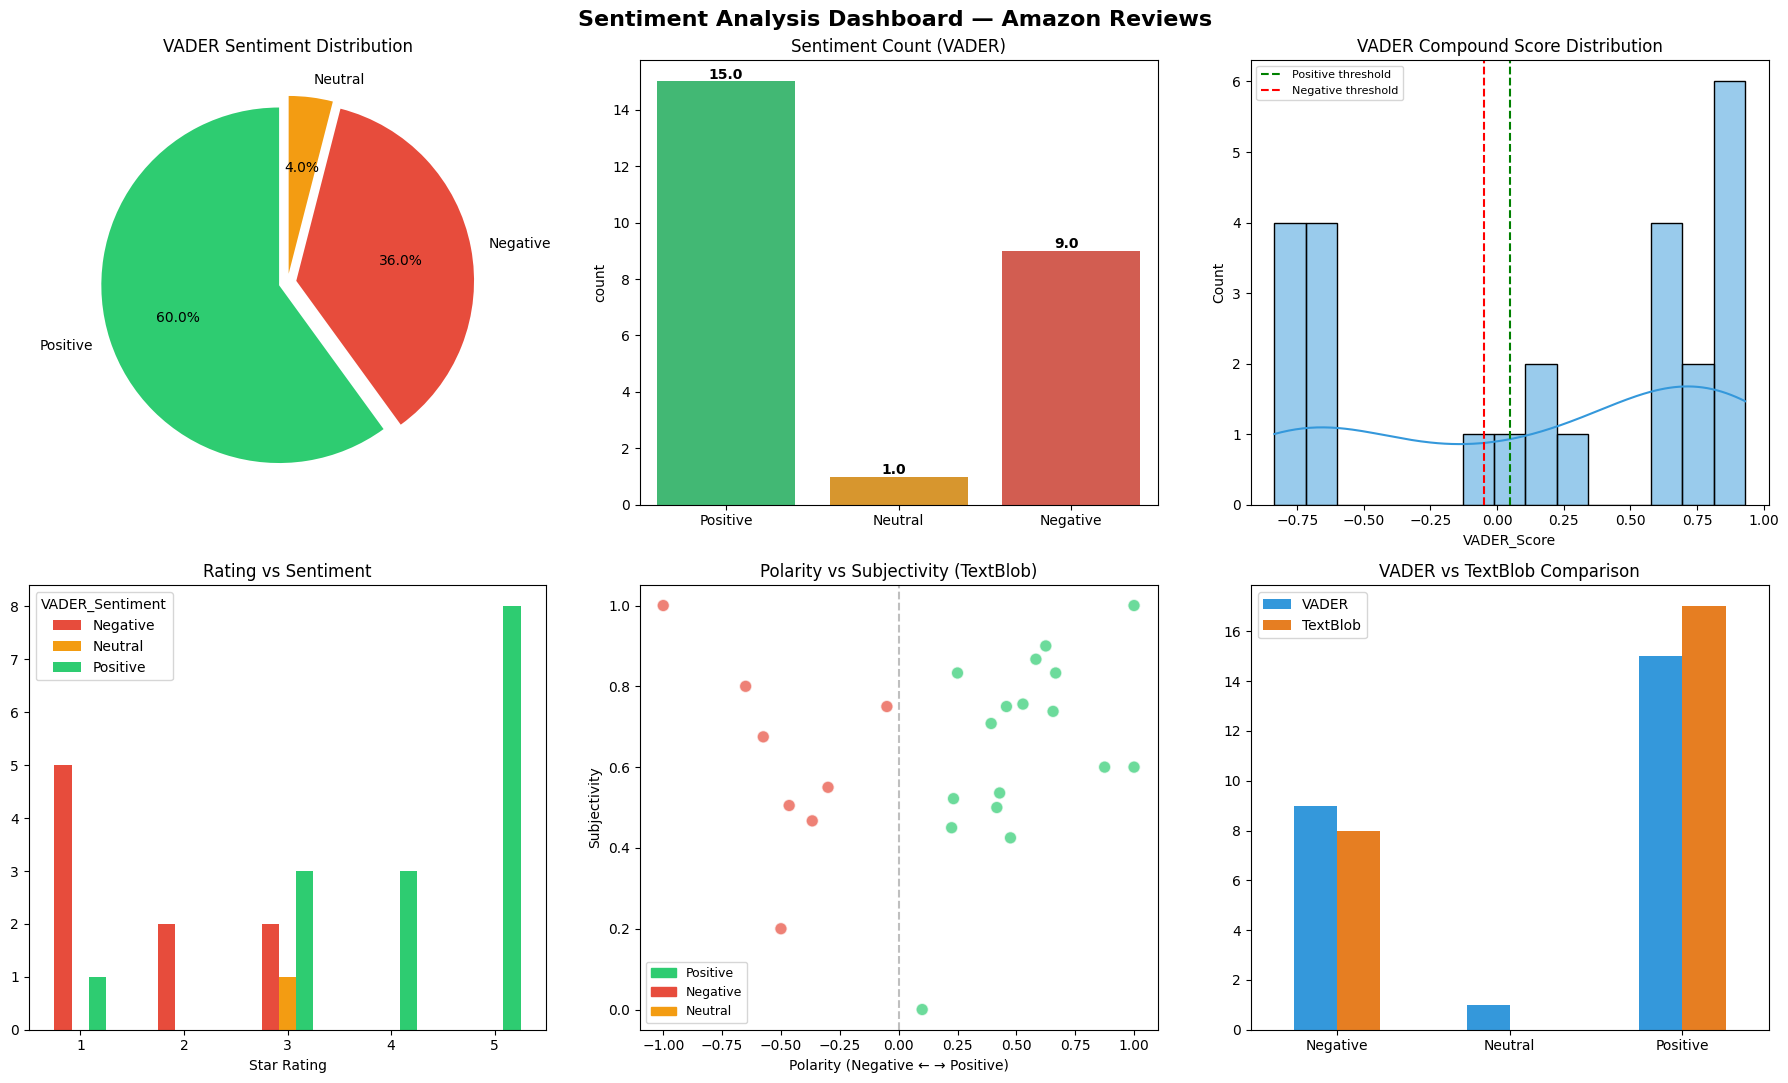

✅ Sentiment dashboard saved!


In [7]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Sentiment Analysis Dashboard — Amazon Reviews', fontsize=16, fontweight='bold')

colors_sentiment = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#f39c12'}

# 1. VADER Sentiment Pie Chart
vader_counts = df_reviews['VADER_Sentiment'].value_counts()
c = [colors_sentiment[k] for k in vader_counts.index]
axes[0,0].pie(vader_counts, labels=vader_counts.index, autopct='%1.1f%%',
              colors=c, startangle=90, explode=[0.05]*len(vader_counts))
axes[0,0].set_title('VADER Sentiment Distribution')

# 2. VADER Sentiment Bar Chart
sns.countplot(x='VADER_Sentiment', data=df_reviews,
              palette=colors_sentiment,
              order=['Positive', 'Neutral', 'Negative'],
              ax=axes[0,1])
axes[0,1].set_title('Sentiment Count (VADER)')
axes[0,1].set_xlabel('')
for p in axes[0,1].patches:
    axes[0,1].annotate(f'{p.get_height()}',
                        (p.get_x()+0.3, p.get_height()+0.1),
                        fontweight='bold')

# 3. VADER Score Distribution
sns.histplot(data=df_reviews, x='VADER_Score', bins=15,
             color='#3498db', ax=axes[0,2], kde=True)
axes[0,2].axvline(x=0.05, color='green', linestyle='--', label='Positive threshold')
axes[0,2].axvline(x=-0.05, color='red', linestyle='--', label='Negative threshold')
axes[0,2].set_title('VADER Compound Score Distribution')
axes[0,2].legend(fontsize=8)

# 4. Rating vs Sentiment
rating_sentiment = df_reviews.groupby(['Rating', 'VADER_Sentiment']).size().unstack(fill_value=0)
rating_sentiment.plot(kind='bar', ax=axes[1,0],
                      color=[colors_sentiment.get(c, '#999') for c in rating_sentiment.columns])
axes[1,0].set_title('Rating vs Sentiment')
axes[1,0].set_xlabel('Star Rating')
axes[1,0].tick_params(axis='x', rotation=0)

# 5. Polarity vs Subjectivity Scatter
scatter_colors = [colors_sentiment[s] for s in df_reviews['TB_Sentiment']]
axes[1,1].scatter(df_reviews['TB_Polarity'], df_reviews['TB_Subjectivity'],
                   c=scatter_colors, alpha=0.7, s=80, edgecolors='white')
axes[1,1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1,1].set_xlabel('Polarity (Negative ← → Positive)')
axes[1,1].set_ylabel('Subjectivity')
axes[1,1].set_title('Polarity vs Subjectivity (TextBlob)')
patches = [mpatches.Patch(color=v, label=k) for k,v in colors_sentiment.items()]
axes[1,1].legend(handles=patches, fontsize=9)

# 6. Comparison: VADER vs TextBlob
comparison_data = pd.DataFrame({
    'VADER': df_reviews['VADER_Sentiment'].value_counts(),
    'TextBlob': df_reviews['TB_Sentiment'].value_counts()
}).fillna(0)
comparison_data.plot(kind='bar', ax=axes[1,2], color=['#3498db','#e67e22'])
axes[1,2].set_title('VADER vs TextBlob Comparison')
axes[1,2].set_xlabel('')
axes[1,2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('sentiment_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sentiment dashboard saved!")

##Step 8 — Word Clouds

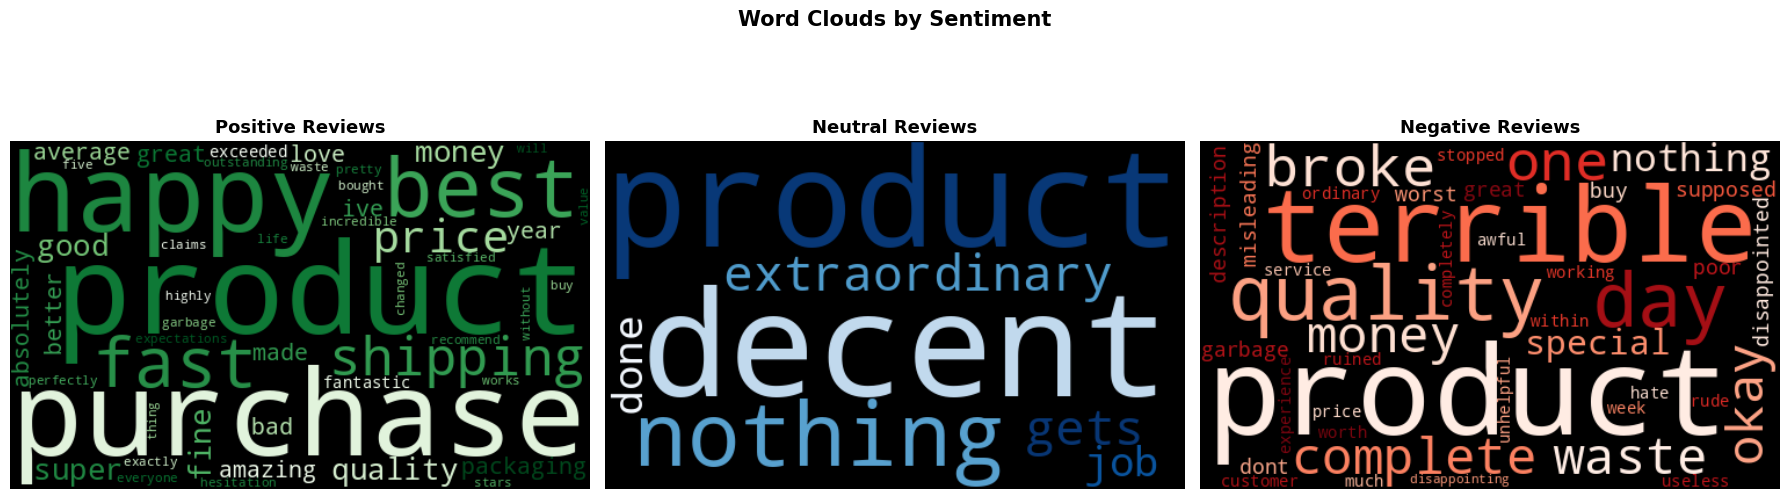

✅ Word clouds saved!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Word Clouds by Sentiment', fontsize=15, fontweight='bold')

for ax, sentiment, colormap in zip(axes,
                                    ['Positive', 'Neutral', 'Negative'],
                                    ['Greens', 'Blues', 'Reds']):
    subset = df_reviews[df_reviews['VADER_Sentiment'] == sentiment]
    if len(subset) > 0:
        text = ' '.join(subset['Cleaned_Review'].tolist())
        wordcloud = WordCloud(width=500, height=300,
                              background_color='black',
                              colormap=colormap,
                              max_words=50).generate(text)
        ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f'{sentiment} Reviews', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()
print("✅ Word clouds saved!")

##Step 9 — Final Report

In [9]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         SENTIMENT ANALYSIS REPORT — AMAZON REVIEWS          ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset: 25 product reviews across 25 categories           ║
║  Methods: VADER + TextBlob (NLP dual approach)              ║
╠══════════════════════════════════════════════════════════════╣
║  VADER Results:                                              ║""")

for sentiment, count in df_reviews['VADER_Sentiment'].value_counts().items():
    pct = count/len(df_reviews)*100
    bar = '█' * int(pct/5)
    print(f"║    {sentiment:<12} {bar:<20} {count:>2} ({pct:.0f}%)              ║")

print(f"""╠══════════════════════════════════════════════════════════════╣
║  Avg Polarity Score: {df_reviews['VADER_Score'].mean():.3f}                              ║
║  Most Common: {df_reviews['VADER_Sentiment'].mode()[0]:<20}                      ║
╚══════════════════════════════════════════════════════════════╝""")


╔══════════════════════════════════════════════════════════════╗
║         SENTIMENT ANALYSIS REPORT — AMAZON REVIEWS          ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset: 25 product reviews across 25 categories           ║
║  Methods: VADER + TextBlob (NLP dual approach)              ║
╠══════════════════════════════════════════════════════════════╣
║  VADER Results:                                              ║
║    Positive     ████████████         15 (60%)              ║
║    Negative     ███████               9 (36%)              ║
║    Neutral                            1 (4%)              ║
╠══════════════════════════════════════════════════════════════╣
║  Avg Polarity Score: 0.167                              ║
║  Most Common: Positive                                  ║
╚══════════════════════════════════════════════════════════════╝
